# 03 — XGBoost Model with Cross-Validation

This notebook trains and evaluates an XGBoost classifier using cross-validation
for robust Parkinson’s Disease detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    RocCurveDisplay
)

from xgboost import XGBClassifier

In [2]:
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "processed" / "pd_cleaned.csv"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "status"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(df.shape)

(224, 17)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("CV F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))
print("Std CV F1:", np.std(cv_scores))

CV F1 scores: [0.96103896 0.92105263 0.96103896 0.94871795 0.92307692]
Mean CV F1: 0.9429850850903483
Std CV F1: 0.017675508652884683


In [7]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [8]:
y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [9]:
xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "mcc": matthews_corrcoef(y_test, y_pred),
    "cv_f1_mean": np.mean(cv_scores),
    "cv_f1_std": np.std(cv_scores)
}

xgb_metrics

{'model': 'XGBoost',
 'accuracy': 0.9333333333333333,
 'precision': 0.925,
 'recall': 1.0,
 'f1_score': 0.961038961038961,
 'roc_auc': 0.9358108108108107,
 'mcc': 0.7603453162872774,
 'cv_f1_mean': 0.9429850850903483,
 'cv_f1_std': 0.017675508652884683}

In [10]:
pd.DataFrame([xgb_metrics]).to_csv(
    METRICS_DIR / "xgboost_metrics.csv",
    index=False
)

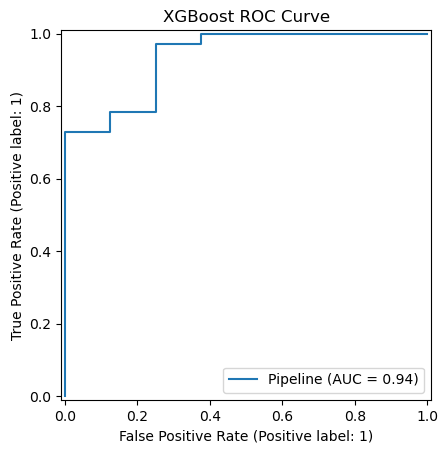

In [11]:
RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test)

plt.title("XGBoost ROC Curve")
plt.savefig(FIGURES_DIR / "xgboost_roc_curve.png", dpi=300)
plt.show()

In [12]:
model = xgb_pipeline.named_steps["model"]

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(15)

,feature,importance
10,vAm,0.132138
0,jitt,0.114906
5,vfo,0.088301
13,VTI,0.073158
6,shim,0.068224
12,FTRI,0.067687
2,RAP,0.065401
3,PPQ,0.061906
15,NHR,0.060797
14,SPI,0.059657


In [13]:
importance.to_csv(
    METRICS_DIR / "xgboost_feature_importance.csv",
    index=False
)

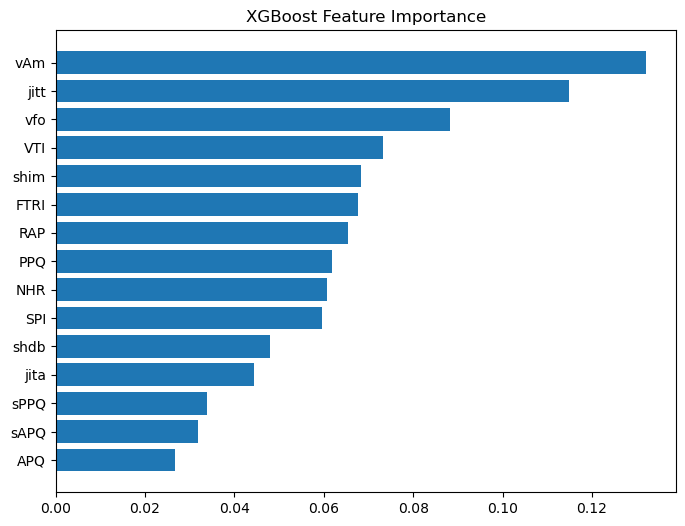

In [14]:
top = importance.head(15).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.title("XGBoost Feature Importance")
plt.savefig(FIGURES_DIR / "xgboost_feature_importance.png", dpi=300)
plt.show()

## XGBoost Summary

XGBoost provides improved performance compared to baseline models.

Cross-validation confirms model stability:
- Mean CV F1 score indicates generalization performance
- Standard deviation shows robustness across folds

This strengthens confidence in the model for real-world biomedical applications.